# RFUAV Experiment 5 — Noisy Drone RF Signal Classification with ResNet18

This notebook is a cleaned Colab workflow for the **Kaggle Noisy Drone RF Signal Classification** dataset.

Main goals:

1. Check GPU, RAM, and disk space.
2. Download the Kaggle dataset safely.
3. Load the large `dataset.pt` file with `mmap=True` so Colab RAM does not crash.
4. Create a balanced 7-class subset.
5. Train a **ResNet18 model modified for 2-channel RF spectrogram tensors**.
6. Evaluate with a classification report, confusion matrix, and accuracy-by-SNR plot.

The dataset provides both raw IQ and spectrogram tensors. This notebook uses:

```text
x_spec: [number_of_samples, 2, 128, 128]
```

## 1. Check GPU, RAM, and disk

Use this first to confirm whether Colab has a GPU and enough disk/RAM.


In [1]:
import os
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected. Go to Runtime → Change runtime type → GPU.")

print("\nRAM:")
!free -h

print("\nDisk:")
!df -h /content


CUDA available: True
GPU: Tesla T4

RAM:
               total        used        free      shared  buff/cache   available
Mem:            12Gi       994Mi       7.6Gi       2.0Mi       4.1Gi        11Gi
Swap:             0B          0B          0B

Disk:
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   48G   66G  42% /


## 2. Install Kaggle package

The `!` symbol runs a Linux shell command inside Colab.


In [2]:
%pip install -q kaggle

## 3. Set up Kaggle credentials safely

Run this cell and paste your Kaggle username and API key when prompted.

Do **not** write your key directly into the notebook.


In [6]:
import os
import getpass

os.environ["KAGGLE_USERNAME"] = input("Kaggle username: ")
os.environ["KAGGLE_KEY"] = getpass.getpass("Kaggle API key: ")

print("Kaggle credentials set for this Colab session only.")


Kaggle credentials set for this Colab session only.


## 4. Test Kaggle access


In [10]:
!kaggle datasets list -s "noisy drone rf signal classification"


ref                                                     title                                                  size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------  ---------------------------------------------  ------------  --------------------------  -------------  ---------  ---------------  
sgluege/noisy-drone-rf-signal-classification            Noisy Drone RF Signal Classification            23481212016  2023-06-08 11:41:26.823000           1405         15  0.88235295       
sgluege/noisy-drone-rf-signal-classification-v2         Noisy Drone RF Signal Classification v2        124950870773  2024-06-26 09:36:14.370000           6108          9  0.8125           
nivashne/kalman-based-leo-rf-dataset-for-uav-detection  Kalman-Based LEO RF Dataset for UAV Detection       1551916  2026-03-25 15:44:52.707000             17          1  0.5294118        
cengizhanyapcolu/dronerfattack-dataset                 

## 5. Download the smaller Noisy Drone RF dataset

This dataset is about 25 GB after extraction. Do not use the larger v2 dataset yet.


In [11]:
!rm -rf /content/noisy_drone_rf
!mkdir -p /content/noisy_drone_rf

!kaggle datasets download \
  -d sgluege/noisy-drone-rf-signal-classification \
  -p /content/noisy_drone_rf \
  --unzip \
  --force

!rm -f /content/noisy_drone_rf/noisy-drone-rf-signal-classification.zip

!ls -lh /content/noisy_drone_rf

import torch
import os

path = "/content/noisy_drone_rf/dataset.pt"

print("File size GB:", os.path.getsize(path) / 1024**3)

data = torch.load(
    path,
    map_location="cpu",
    mmap=True,
    weights_only=False
)

print("Loaded successfully")
print(data.keys())

Dataset URL: https://www.kaggle.com/datasets/sgluege/noisy-drone-rf-signal-classification
License(s): Attribution 4.0 International (CC BY 4.0)
100% 21.9G/21.9G [03:31<00:00, 111MB/s] 

total 25G
-rw-r--r-- 1 root root 143 Jun 16 04:03 class_stats.csv
-rw-r--r-- 1 root root 25G Jun 16 04:08 dataset.pt
-rw-r--r-- 1 root root 288 Jun 16 04:03 SNR_stats.csv
File size GB: 24.099373045377433
Loaded successfully
dict_keys(['x_iq', 'x_spec', 'y', 'snr', 'duty_cycle'])


## 6. Inspect class and SNR statistics

This shows the class imbalance and SNR distribution.


In [12]:
import pandas as pd

class_stats_path = "/content/noisy_drone_rf/class_stats.csv"
snr_stats_path = "/content/noisy_drone_rf/SNR_stats.csv"

class_stats = pd.read_csv(class_stats_path)
snr_stats = pd.read_csv(snr_stats_path)

print("Class stats:")
display(class_stats)

print("SNR stats:")
display(snr_stats)


Class stats:


,Unnamed: 0,class,class_int,count
0,0,DJI,0,2194
1,1,FutabaT14,1,6938
2,2,FutabaT7,2,3661
3,3,Graupner,3,6481
4,4,Noise,4,52552
5,5,Taranis,5,16546
6,6,Turnigy,6,10333


SNR stats:


,Unnamed: 0,SNR,count
0,0,-20,3792
1,1,-18,3795
2,2,-16,3796
3,3,-14,3796
4,4,-12,3797
5,5,-10,3796
6,6,-8,3795
7,7,-6,3795
8,8,-4,3798
9,9,-2,3798


## 7. Safely load `dataset.pt` with memory mapping

`dataset.pt` is around 24–25 GB, so normal `torch.load()` can crash Colab RAM.

Always use:

```python
torch.load(path, map_location="cpu", mmap=True, weights_only=False)
```


In [13]:
import torch
import os

path = "/content/noisy_drone_rf/dataset.pt"
print("File size GB:", os.path.getsize(path) / 1024**3)

print("Before loading:")
!free -h

data = torch.load(
    path,
    map_location="cpu",
    mmap=True,
    weights_only=False
)

print("Loaded successfully with mmap")
print("Type:", type(data))

for k, v in data.items():
    print(k, type(v), getattr(v, "shape", None), getattr(v, "dtype", None))

print("After loading:")
!free -h


File size GB: 24.099373045377433
Before loading:
               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.0Gi       2.5Gi       2.0Mi       9.1Gi        11Gi
Swap:             0B          0B          0B
Loaded successfully with mmap
Type: <class 'dict'>
x_iq <class 'torch.Tensor'> torch.Size([98705, 2, 16384]) torch.float32
x_spec <class 'torch.Tensor'> torch.Size([98705, 2, 128, 128]) torch.float32
y <class 'torch.Tensor'> torch.Size([98705]) torch.int64
snr <class 'torch.Tensor'> torch.Size([98705]) torch.int32
duty_cycle <class 'torch.Tensor'> torch.Size([98705]) torch.float32
After loading:
               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.0Gi       2.5Gi       2.0Mi       9.1Gi        11Gi
Swap:             0B          0B          0B


## 8. Create a balanced 7-class subset

The full dataset is imbalanced because the `Noise` class is much larger than the smallest class.

For a fair first experiment, use:

- 1700 training samples per class
- 400 validation samples per class
- 7 classes total

In [14]:
import numpy as np
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

class_names = [
    "DJI",
    "FutabaT14",
    "FutabaT7",
    "Graupner",
    "Noise",
    "Taranis",
    "Turnigy"
]

y = data["y"]

train_per_class = 1700
valid_per_class = 400

train_indices = []
valid_indices = []

for cls, name in enumerate(class_names):
    cls_indices = torch.where(y == cls)[0].cpu().numpy()
    np.random.shuffle(cls_indices)

    needed = train_per_class + valid_per_class
    if len(cls_indices) < needed:
        raise ValueError(f"Class {name} has only {len(cls_indices)} samples, but {needed} are needed.")

    train_indices.extend(cls_indices[:train_per_class])
    valid_indices.extend(cls_indices[train_per_class:train_per_class + valid_per_class])

train_indices = np.array(train_indices)
valid_indices = np.array(valid_indices)

np.random.shuffle(train_indices)
np.random.shuffle(valid_indices)

print("Train samples:", len(train_indices))
print("Valid samples:", len(valid_indices))

for cls, name in enumerate(class_names):
    train_count = int((y[train_indices] == cls).sum().item())
    valid_count = int((y[valid_indices] == cls).sum().item())
    print(f"{name}: train={train_count}, valid={valid_count}")


Train samples: 11900
Valid samples: 2800
DJI: train=1700, valid=400
FutabaT14: train=1700, valid=400
FutabaT7: train=1700, valid=400
Graupner: train=1700, valid=400
Noise: train=1700, valid=400
Taranis: train=1700, valid=400
Turnigy: train=1700, valid=400


## 9. Build a PyTorch Dataset and DataLoader for `x_spec`

`x_spec` has shape:

```text
[number_of_samples, 2, 128, 128]
```

So the CNN input channel count must be `2`.


In [15]:
from torch.utils.data import Dataset, DataLoader

class NoisyDroneSpecDataset(Dataset):
    def __init__(self, data, indices):
        self.x_spec = data["x_spec"]
        self.y = data["y"]
        self.snr = data["snr"]
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = int(self.indices[idx])
        x = self.x_spec[real_idx]   # [2, 128, 128]
        label = self.y[real_idx]
        snr = self.snr[real_idx]
        return x, label, snr

batch_size = 64
num_workers = 0  # Safer for Colab + memory-mapped tensors
pin_memory = torch.cuda.is_available()

train_dataset = NoisyDroneSpecDataset(data, train_indices)
valid_dataset = NoisyDroneSpecDataset(data, valid_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory
)

x_batch, y_batch, snr_batch = next(iter(train_loader))
print("x batch:", x_batch.shape)
print("y batch:", y_batch.shape)
print("snr batch:", snr_batch.shape)
print("x dtype:", x_batch.dtype)
print("y dtype:", y_batch.dtype)
print("snr dtype:", snr_batch.dtype)


x batch: torch.Size([64, 2, 128, 128])
y batch: torch.Size([64])
snr batch: torch.Size([64])
x dtype: torch.float32
y dtype: torch.int64
snr dtype: torch.int32


## 10. Define ResNet18 for 2-channel RF spectrograms

Normal ResNet18 expects RGB images with shape:

```text
[batch, 3, height, width]
```

This dataset uses RF spectrogram tensors with shape:

```text
[batch, 2, 128, 128]
```

So we modify the first convolution layer to accept 2 input channels and change the final fully connected layer to output 7 classes.

For this RF dataset, we use `weights=None` because ImageNet pretrained weights are designed for natural RGB images, not 2-channel RF spectrograms.


In [16]:
import torch.nn as nn
from torchvision import models

class ResNet18RFSpec(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        # Start with a standard ResNet18 architecture.
        # weights=None avoids RGB ImageNet pretrained weights.
        self.model = models.resnet18(weights=None)

        # Original ResNet18 first layer expects 3-channel RGB images.
        # Our RF spectrogram tensors have 2 channels, so change 3 -> 2.
        self.model.conv1 = nn.Conv2d(
            in_channels=2,
            out_channels=64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )

        # Replace the final classifier for 7 drone/noise classes.
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        return self.model(x)

# Quick shape test before training.
model_test = ResNet18RFSpec(num_classes=7)
with torch.no_grad():
    out = model_test(x_batch[:2])
print("Test output shape:", out.shape)


Test output shape: torch.Size([2, 7])


## 11. Mount Google Drive for saving results

This cell is optional but recommended. If Drive is not mounted, results are saved in `/content/noisy_drone_results`.


In [29]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_DIR = "/content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced"
except Exception as e:
    print("Drive mount failed or not available:", e)
    SAVE_DIR = "/content/noisy_drone_results/noisy_drone_resnet18_spec_balanced"

os.makedirs(SAVE_DIR, exist_ok=True)
print("Save directory:", SAVE_DIR)


Mounted at /content/drive
Save directory: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced


## 12. Train ResNet18

This trains ResNet18 on the balanced spectrogram subset and saves:

- `best.pt`
- `last.pt`
- `history.csv`

Start with `batch_size = 64`. If Colab gives a CUDA out-of-memory error, go back to the DataLoader cell and reduce `batch_size` to `32`.


In [30]:
import torch.optim as optim
from tqdm import tqdm
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = ResNet18RFSpec(num_classes=len(class_names)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20  # You can reduce to 10 for a faster first test
history = []
best_acc = 0.0

for epoch in range(epochs):
    print("=" * 60)
    print(f"Epoch {epoch + 1}/{epochs}")

    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for x, labels, snrs in tqdm(train_loader, desc="Training"):
        x = x.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * x.size(0)
        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    model.eval()
    valid_loss = 0.0
    valid_correct = 0
    valid_total = 0

    with torch.no_grad():
        for x, labels, snrs in tqdm(valid_loader, desc="Validation"):
            x = x.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(x)
            loss = criterion(outputs, labels)

            valid_loss += loss.item() * x.size(0)
            preds = outputs.argmax(dim=1)
            valid_correct += (preds == labels).sum().item()
            valid_total += labels.size(0)

    valid_loss /= valid_total
    valid_acc = valid_correct / valid_total

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc : {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f}")
    print(f"Valid Acc : {valid_acc:.4f}")

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "valid_loss": valid_loss,
        "valid_acc": valid_acc,
    })

    if valid_acc > best_acc:
        best_acc = valid_acc
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, "best.pt"))
        print("Saved best model.")

torch.save(model.state_dict(), os.path.join(SAVE_DIR, "last.pt"))
history_df = pd.DataFrame(history)
history_df.to_csv(os.path.join(SAVE_DIR, "history.csv"), index=False)

print("Finished.")
print("Best valid accuracy:", best_acc)
print("Saved to:", SAVE_DIR)


Using device: cuda
Epoch 1/20


Validation: 100%|██████████| 44/44 [00:00<00:00, 47.51it/s]


Train Loss: 1.2623
Train Acc : 0.5307
Valid Loss: 0.9030
Valid Acc : 0.6693
Saved best model.
Epoch 2/20


Validation: 100%|██████████| 44/44 [00:00<00:00, 47.62it/s]


Train Loss: 0.7487
Train Acc : 0.7306
Valid Loss: 0.7686
Valid Acc : 0.7486
Saved best model.
Epoch 3/20


...

Train Loss: 0.0376
Train Acc : 0.9883
Valid Loss: 0.9659
Valid Acc : 0.8107
Epoch 19/20


Validation: 100%|██████████| 44/44 [00:00<00:00, 47.85it/s]


Train Loss: 0.0463
Train Acc : 0.9855
Valid Loss: 0.9010
Valid Acc : 0.8246
Epoch 20/20


Validation: 100%|██████████| 44/44 [00:00<00:00, 47.12it/s]


Train Loss: 0.0519
Train Acc : 0.9844
Valid Loss: 0.7739
Valid Acc : 0.8154
Finished.
Best valid accuracy: 0.8314285714285714
Saved to: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced


## 13. Plot training curves


,epoch,train_loss,train_acc,valid_loss,valid_acc
0,1,1.262268,0.530672,0.902990,0.669286
1,2,0.748677,0.730588,0.768615,0.748571
2,3,0.596820,0.786134,0.686799,0.757500
3,4,0.482120,0.828908,0.524891,0.817143
4,5,0.393075,0.863445,0.611271,0.800357
5,6,0.327638,0.884706,0.650916,0.787500
6,7,0.254230,0.912101,0.571551,0.823929
7,8,0.216862,0.925126,0.598670,0.818214
8,9,0.148914,0.949916,0.657447,0.813929
9,10,0.129021,0.956807,0.807478,0.814643


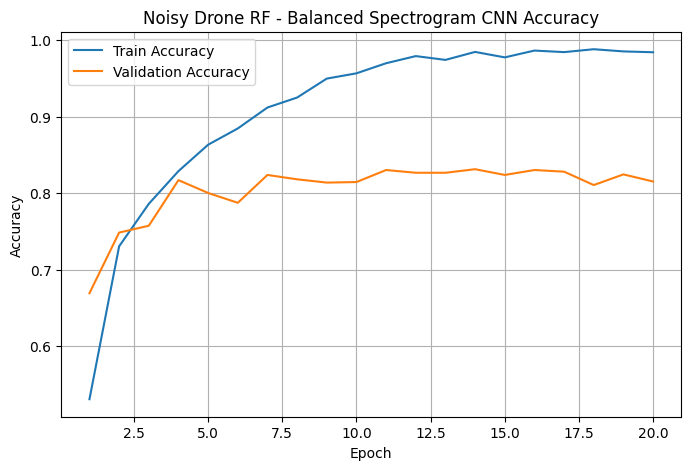

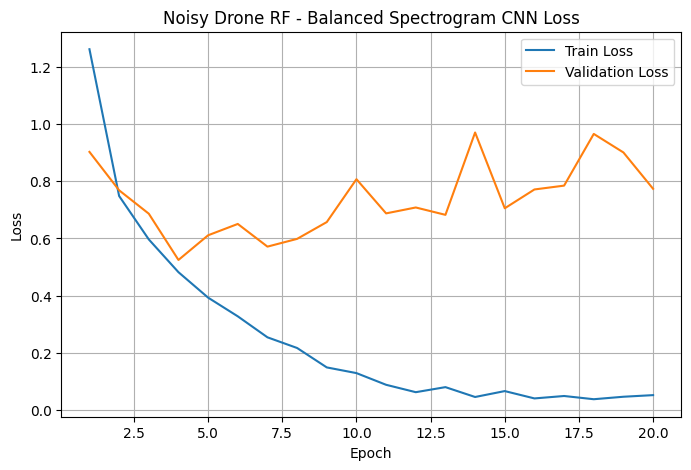

In [37]:
import matplotlib.pyplot as plt

history_path = os.path.join(SAVE_DIR, "history.csv")
history_df = pd.read_csv(history_path)
display(history_df)

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_acc"], label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["valid_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Noisy Drone RF - Balanced Spectrogram CNN Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["valid_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Noisy Drone RF - Balanced Spectrogram CNN Loss")
plt.legend()
plt.grid(True)
plt.show()


## 14. Classification report and confusion matrix

Use macro F1 because this dataset is naturally imbalanced, even though this first subset is balanced.


Loaded best model: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced/best.pt
              precision    recall  f1-score   support

         DJI       0.95      0.83      0.89       400
   FutabaT14       0.92      0.78      0.84       400
    FutabaT7       0.85      0.81      0.83       400
    Graupner       0.99      0.87      0.93       400
       Noise       0.55      0.89      0.68       400
     Taranis       0.96      0.90      0.93       400
     Turnigy       0.83      0.74      0.78       400

    accuracy                           0.83      2800
   macro avg       0.86      0.83      0.84      2800
weighted avg       0.86      0.83      0.84      2800



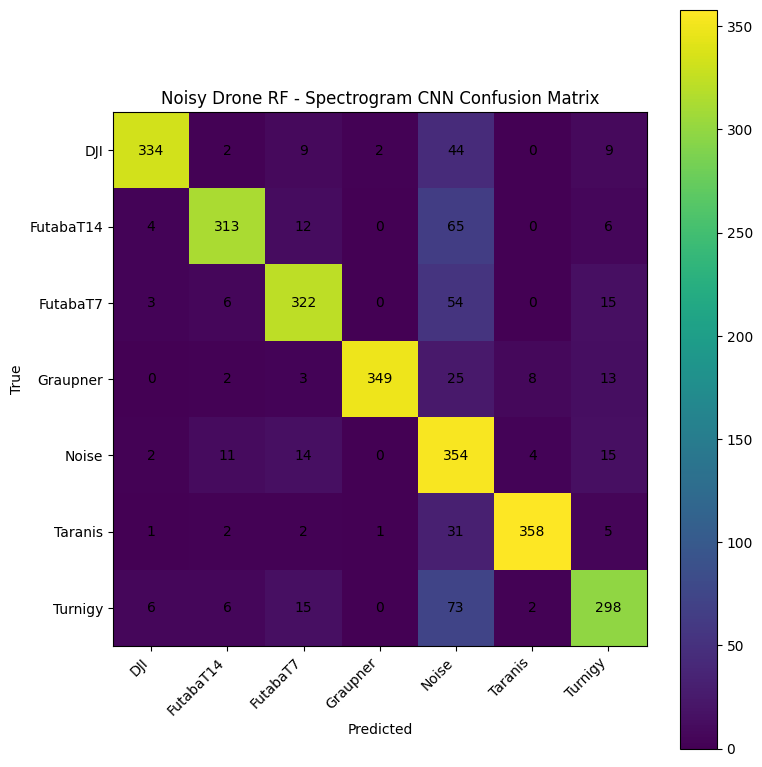

Saved confusion matrix to: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced/confusion_matrix.png


In [39]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Load best model before evaluation
best_path = os.path.join(SAVE_DIR, "best.pt")
if os.path.exists(best_path):
    model.load_state_dict(torch.load(best_path, map_location=device))
    print("Loaded best model:", best_path)

model.eval()
all_preds = []
all_labels = []
all_snrs = []

with torch.no_grad():
    for x, labels, snrs in valid_loader:
        x = x.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        outputs = model(x)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_snrs.extend(snrs.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 8))
plt.imshow(cm)
plt.title("Noisy Drone RF - Spectrogram CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(np.arange(len(class_names)), class_names)
plt.colorbar()

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
cm_path = os.path.join(SAVE_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=200)
plt.show()
print("Saved confusion matrix to:", cm_path)


## 15. Accuracy by SNR

This is one of the most important analyses for this dataset.

Low SNR values like `-20 dB` should be harder. High SNR values like `20 dB` to `30 dB` should be easier.


,SNR,accuracy
0,-20,0.140187
1,-18,0.234043
2,-16,0.320388
3,-14,0.515873
4,-12,0.578431
5,-10,0.732558
6,-8,0.836538
7,-6,0.931373
8,-4,0.897959
9,-2,0.942623


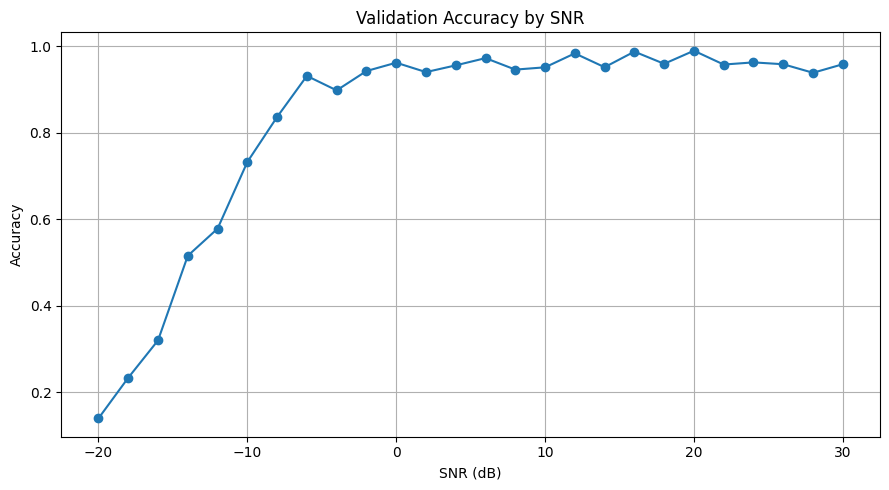

Saved SNR accuracy plot to: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced/accuracy_by_snr.png


In [40]:
results_df = pd.DataFrame({
    "label": all_labels,
    "pred": all_preds,
    "snr": all_snrs,
})
results_df["correct"] = results_df["label"] == results_df["pred"]

snr_acc = results_df.groupby("snr")["correct"].mean().reset_index()
snr_acc.columns = ["SNR", "accuracy"]
display(snr_acc)

plt.figure(figsize=(9, 5))
plt.plot(snr_acc["SNR"], snr_acc["accuracy"], marker="o")
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy by SNR")
plt.grid(True)
plt.tight_layout()
snr_path = os.path.join(SAVE_DIR, "accuracy_by_snr.png")
plt.savefig(snr_path, dpi=200)
plt.show()
print("Saved SNR accuracy plot to:", snr_path)


## 16. Confusion matrices by SNR group

The overall confusion matrix hides where the model fails. This section splits the validation set into low, medium, and high SNR groups, then creates a separate confusion matrix for each group.

Suggested groups:

```text
Low SNR:    -20 to -10 dB
Medium SNR: -8 to 4 dB
High SNR:    6 to 30 dB
```

This helps show whether errors such as `Turnigy → Noise` mainly happen when the RF signal is weak.


low_snr_-20_to_-10: SNR -20 to -10 dB
Samples: 618
Accuracy: 0.4159

Classification report:
              precision    recall  f1-score   support

         DJI       0.77      0.30      0.43        81
   FutabaT14       0.44      0.14      0.21        88
    FutabaT7       0.45      0.24      0.31        88
    Graupner       0.96      0.49      0.65        87
       Noise       0.23      0.92      0.37        87
     Taranis       0.90      0.53      0.67        86
     Turnigy       0.42      0.31      0.36       101

    accuracy                           0.42       618
   macro avg       0.60      0.42      0.43       618
weighted avg       0.59      0.42      0.43       618



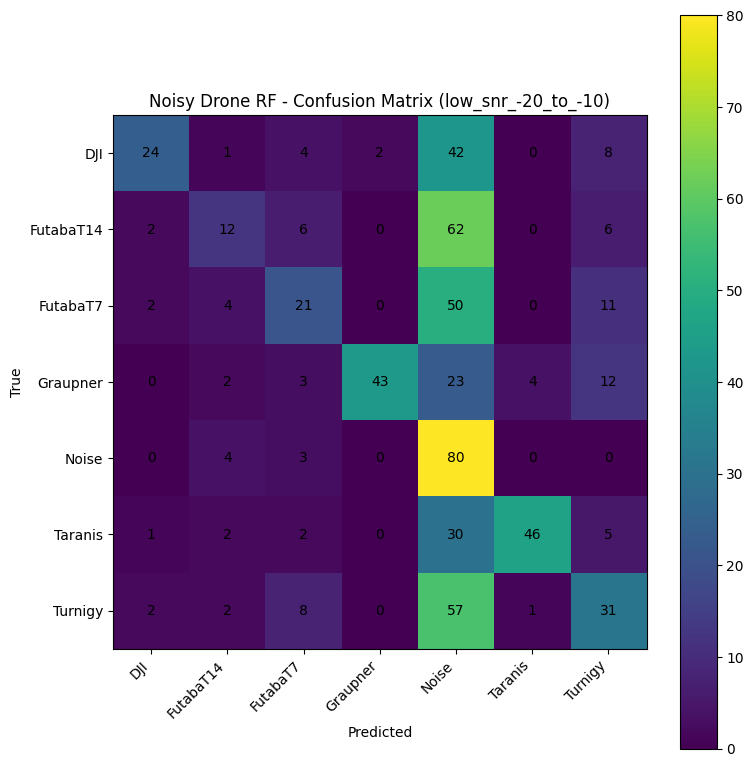

Saved: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced/confusion_matrix_low_snr_-20_to_-10.png
medium_snr_-8_to_4: SNR -8 to 4 dB
Samples: 761
Accuracy: 0.9251

Classification report:
              precision    recall  f1-score   support

         DJI       0.95      0.95      0.95       112
   FutabaT14       0.95      0.94      0.95       112
    FutabaT7       0.89      0.92      0.90       106
    Graupner       1.00      0.96      0.98       119
       Noise       0.82      0.90      0.86       104
     Taranis       0.95      0.99      0.97       111
     Turnigy       0.91      0.80      0.85        97

    accuracy                           0.93       761
   macro avg       0.92      0.92      0.92       761
weighted avg       0.93      0.93      0.93       761



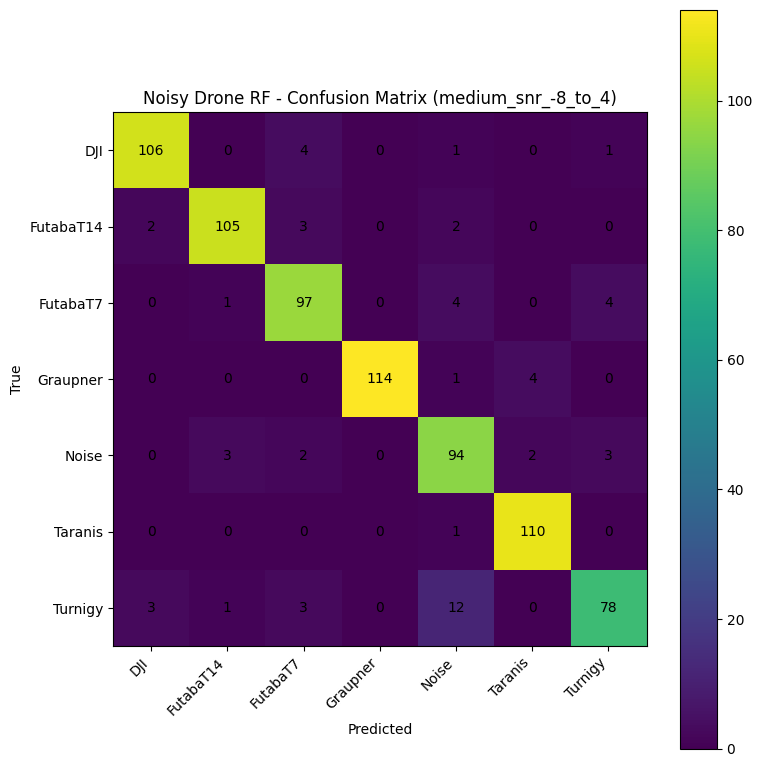

Saved: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced/confusion_matrix_medium_snr_-8_to_4.png
high_snr_6_to_30: SNR 6 to 30 dB
Samples: 1421
Accuracy: 0.9620

Classification report:
              precision    recall  f1-score   support

         DJI       0.98      0.99      0.98       207
   FutabaT14       0.96      0.98      0.97       200
    FutabaT7       0.92      0.99      0.96       206
    Graupner       0.99      0.99      0.99       194
       Noise       0.96      0.86      0.91       209
     Taranis       0.99      1.00      0.99       203
     Turnigy       0.94      0.94      0.94       202

    accuracy                           0.96      1421
   macro avg       0.96      0.96      0.96      1421
weighted avg       0.96      0.96      0.96      1421



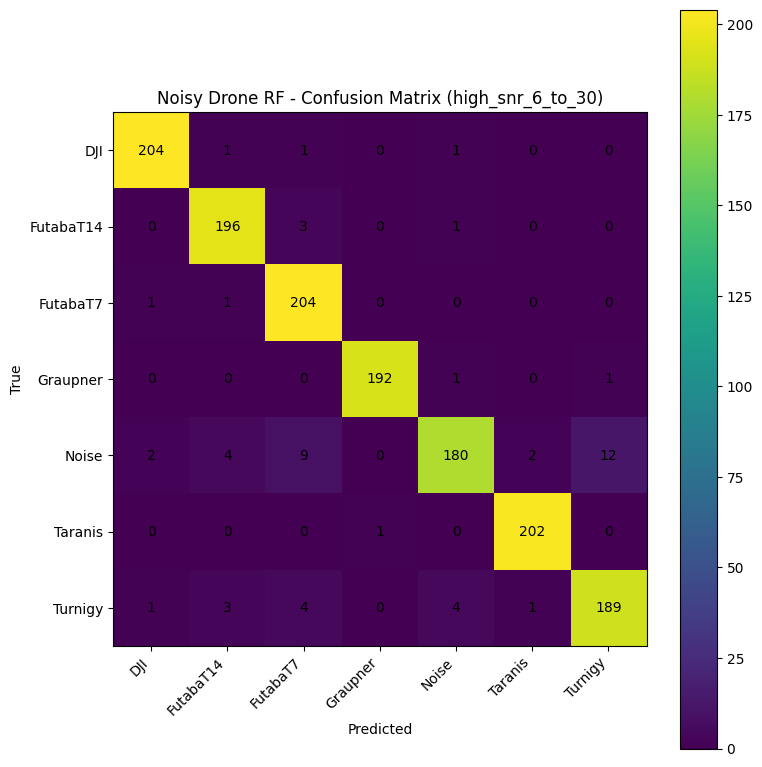

Saved: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced/confusion_matrix_high_snr_6_to_30.png


,group,snr_min,snr_max,samples,accuracy
0,low_snr_-20_to_-10,-20,-10,618,0.415858
1,medium_snr_-8_to_4,-8,4,761,0.925099
2,high_snr_6_to_30,6,30,1421,0.961999


Saved SNR group summary to: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced/snr_group_summary.csv


In [41]:

from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# This cell expects these variables from the evaluation cell:
# all_labels, all_preds, all_snrs, class_names, SAVE_DIR

results_df = pd.DataFrame({
    "label": np.array(all_labels),
    "pred": np.array(all_preds),
    "snr": np.array(all_snrs),
})

results_df["correct"] = results_df["label"] == results_df["pred"]

snr_groups = {
    "low_snr_-20_to_-10": (-20, -10),
    "medium_snr_-8_to_4": (-8, 4),
    "high_snr_6_to_30": (6, 30),
}

def plot_confusion_matrix_for_subset(df_subset, title, save_path):
    labels = list(range(len(class_names)))
    cm = confusion_matrix(df_subset["label"], df_subset["pred"], labels=labels)

    plt.figure(figsize=(8, 8))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
    plt.yticks(np.arange(len(class_names)), class_names)
    plt.colorbar()

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            plt.text(j, i, int(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()

    return cm

snr_summary_rows = []

for group_name, (snr_min, snr_max) in snr_groups.items():
    subset = results_df[(results_df["snr"] >= snr_min) & (results_df["snr"] <= snr_max)].copy()

    if len(subset) == 0:
        print(f"No validation samples found for {group_name}")
        continue

    acc = subset["correct"].mean()
    print("=" * 80)
    print(f"{group_name}: SNR {snr_min} to {snr_max} dB")
    print(f"Samples: {len(subset)}")
    print(f"Accuracy: {acc:.4f}")

    print("\nClassification report:")
    print(classification_report(
        subset["label"],
        subset["pred"],
        labels=list(range(len(class_names))),
        target_names=class_names,
        zero_division=0,
    ))

    save_path = os.path.join(SAVE_DIR, f"confusion_matrix_{group_name}.png")
    cm_group = plot_confusion_matrix_for_subset(
        subset,
        f"Noisy Drone RF - Confusion Matrix ({group_name})",
        save_path
    )
    print("Saved:", save_path)

    snr_summary_rows.append({
        "group": group_name,
        "snr_min": snr_min,
        "snr_max": snr_max,
        "samples": len(subset),
        "accuracy": acc,
    })

snr_group_summary = pd.DataFrame(snr_summary_rows)
display(snr_group_summary)

summary_path = os.path.join(SAVE_DIR, "snr_group_summary.csv")
snr_group_summary.to_csv(summary_path, index=False)
print("Saved SNR group summary to:", summary_path)


## 17. Per-class recall by SNR group

This table shows which class gets worse when SNR is low. A low recall means many samples from that true class are being predicted as another class, often `Noise`.


In [42]:

# Per-class recall by SNR group
per_class_rows = []

for group_name, (snr_min, snr_max) in snr_groups.items():
    subset = results_df[(results_df["snr"] >= snr_min) & (results_df["snr"] <= snr_max)].copy()

    for cls_id, cls_name in enumerate(class_names):
        cls_subset = subset[subset["label"] == cls_id]

        if len(cls_subset) == 0:
            recall = np.nan
            correct = 0
            total = 0
        else:
            correct = int((cls_subset["pred"] == cls_id).sum())
            total = int(len(cls_subset))
            recall = correct / total

        per_class_rows.append({
            "group": group_name,
            "class": cls_name,
            "correct": correct,
            "total": total,
            "recall": recall,
        })

per_class_snr_recall = pd.DataFrame(per_class_rows)
display(per_class_snr_recall)

per_class_path = os.path.join(SAVE_DIR, "per_class_recall_by_snr_group.csv")
per_class_snr_recall.to_csv(per_class_path, index=False)
print("Saved per-class SNR recall table to:", per_class_path)

# Optional: pivot table for easier reading
pivot_recall = per_class_snr_recall.pivot(index="class", columns="group", values="recall")
display(pivot_recall)


,group,class,correct,total,recall
0,low_snr_-20_to_-10,DJI,24,81,0.296296
1,low_snr_-20_to_-10,FutabaT14,12,88,0.136364
2,low_snr_-20_to_-10,FutabaT7,21,88,0.238636
3,low_snr_-20_to_-10,Graupner,43,87,0.494253
4,low_snr_-20_to_-10,Noise,80,87,0.919540
5,low_snr_-20_to_-10,Taranis,46,86,0.534884
6,low_snr_-20_to_-10,Turnigy,31,101,0.306931
7,medium_snr_-8_to_4,DJI,106,112,0.946429
8,medium_snr_-8_to_4,FutabaT14,105,112,0.937500
9,medium_snr_-8_to_4,FutabaT7,97,106,0.915094


Saved per-class SNR recall table to: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced/per_class_recall_by_snr_group.csv


group,high_snr_6_to_30,low_snr_-20_to_-10,medium_snr_-8_to_4
class,,,
DJI,0.985507,0.296296,0.946429
FutabaT14,0.980000,0.136364,0.937500
FutabaT7,0.990291,0.238636,0.915094
Graupner,0.989691,0.494253,0.957983
Noise,0.861244,0.919540,0.903846
Taranis,0.995074,0.534884,0.990991
Turnigy,0.935644,0.306931,0.804124


## 18. Noise-aware training experiment

The SNR-group confusion matrices showed that most errors happen at **low SNR**. This experiment trains a second ResNet18 model using the same architecture, but changes the training procedure so low-SNR samples matter more.

This notebook uses two noise-aware techniques:

1. **SNR-aware oversampling** using `WeightedRandomSampler`  
   Low-SNR training samples are sampled more often during each epoch.

2. **SNR-weighted loss**  
   Mistakes on low-SNR samples receive a larger loss weight.

The validation set is unchanged, so the result can be compared fairly against the original baseline.


In [49]:
from torch.utils.data import WeightedRandomSampler
import numpy as np
import pandas as pd
import os

# Create a separate save folder so the baseline model is not overwritten.
SAVE_DIR_BASELINE = SAVE_DIR
SAVE_DIR_NOISE_AWARE = SAVE_DIR_BASELINE + "_noise_aware"
os.makedirs(SAVE_DIR_NOISE_AWARE, exist_ok=True)

print("Baseline save directory:", SAVE_DIR_BASELINE)
print("Noise-aware save directory:", SAVE_DIR_NOISE_AWARE)

# Training SNR values for the selected training subset.
train_snrs_np = data["snr"][train_indices].cpu().numpy()

# Define SNR groups. These match the evaluation groups used earlier.
def snr_group_name(snr):
    if -20 <= snr <= -10:
        return "low"
    elif -8 <= snr <= 4:
        return "medium"
    elif 6 <= snr <= 30:
        return "high"
    else:
        return "other"

train_snr_groups = np.array([snr_group_name(float(s)) for s in train_snrs_np])
train_snr_dist = pd.Series(train_snr_groups).value_counts().rename_axis("snr_group").reset_index(name="count")
display(train_snr_dist)

# Oversampling weights: make low SNR appear more often during training.
# You can tune these values later. Start simple.
sampler_group_weights = {
    "low": 1.15,
    "medium": 1.05,
    "high": 1.0,
    "other": 1.0,
}

sample_weights = np.array([sampler_group_weights[g] for g in train_snr_groups], dtype=np.float64)

noise_aware_sampler = WeightedRandomSampler(
    weights=torch.as_tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights),
    replacement=True,
)

noise_aware_train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

# Quick check: show the approximate SNR distribution from one sampled epoch.
sampled_group_counts = {"low": 0, "medium": 0, "high": 0, "other": 0}
for _, _, snrs in noise_aware_train_loader:
    for s in snrs.cpu().numpy():
        sampled_group_counts[snr_group_name(float(s))] += 1

sampled_dist = pd.DataFrame([
    {"snr_group": k, "sampled_count_one_epoch": v}
    for k, v in sampled_group_counts.items()
])
display(sampled_dist)


Baseline save directory: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced
Noise-aware save directory: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced_noise_aware


,snr_group,count
0,high,5841
1,medium,3262
2,low,2797


,snr_group,sampled_count_one_epoch
0,low,2797
1,medium,3262
2,high,5841
3,other,0


## 19. Train noise-aware ResNet18

This trains a new ResNet18 model. It does not overwrite the previous baseline results.

Because low-SNR samples are now emphasized, the overall validation accuracy may not always improve immediately. The key thing to check is whether **low-SNR accuracy** improves without damaging medium/high-SNR performance too much.


In [50]:
import os
import numpy as np
import torch
import torch.optim as optim
from tqdm import tqdm
import pandas as pd
import torch.nn.functional as F

set_seed(42)

os.makedirs(SAVE_DIR_NOISE_AWARE, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class_to_idx = {name: idx for idx, name in enumerate(class_names)}
idx_to_class = {idx: name for name, idx in class_to_idx.items()}

print("Class mapping:")
print(class_to_idx)

noise_aware_model = ResNet18RFSpec(num_classes=len(class_names)).to(device)

optimizer = optim.Adam(
    noise_aware_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)


# Noise-protected per-sample loss weights.
# Goal:
# - Slightly improve low-SNR drone samples.
# - Protect the Noise class so Noise recall does not collapse.
def get_noise_protected_loss_weights(snrs, labels, class_to_idx, device):
    weights = torch.ones_like(snrs, dtype=torch.float32, device=device)

    noise_idx = class_to_idx["Noise"]

    is_noise = labels == noise_idx
    is_drone = labels != noise_idx

    low_snr = (snrs >= -20) & (snrs <= -10)
    medium_snr = (snrs >= -8) & (snrs <= 4)
    high_snr = (snrs >= 6) & (snrs <= 30)

    # Mild SNR boost for drone classes only.
    weights[is_drone & low_snr] = 1.15
    weights[is_drone & medium_snr] = 1.05
    weights[is_drone & high_snr] = 1.00

    # Protect Noise because previous runs damaged Noise recall badly.
    weights[is_noise] = 2.00

    return weights


def safe_mean(series):
    if len(series) == 0:
        return np.nan
    return series.mean()


epochs_noise_aware = 20
history_noise_aware = []

best_low_snr_acc = 0.0
best_valid_acc = 0.0
best_protected_score = 0.0

for epoch in range(epochs_noise_aware):
    print("=" * 60)
    print(f"Noise-aware epoch {epoch + 1}/{epochs_noise_aware}")

    # =========================
    # Training
    # =========================
    noise_aware_model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for x, labels, snrs in tqdm(noise_aware_train_loader, desc="Noise-aware training"):
        x = x.to(device, non_blocking=True).float()
        labels = labels.to(device, non_blocking=True).long()
        snrs = snrs.to(device, non_blocking=True).float()

        optimizer.zero_grad()

        outputs = noise_aware_model(x)

        per_sample_loss = F.cross_entropy(
            outputs,
            labels,
            reduction="none"
        )

        sample_weights = get_noise_protected_loss_weights(
            snrs=snrs,
            labels=labels,
            class_to_idx=class_to_idx,
            device=device
        )

        # Important:
        # Use normalized weighted loss, not .mean().
        loss = (per_sample_loss * sample_weights).sum() / sample_weights.sum()

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * x.size(0)

        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    # =========================
    # Validation
    # =========================
    noise_aware_model.eval()

    valid_loss = 0.0
    valid_correct = 0
    valid_total = 0

    valid_labels_epoch = []
    valid_preds_epoch = []
    valid_snrs_epoch = []

    with torch.no_grad():
        for x, labels, snrs in tqdm(valid_loader, desc="Validation"):
            x = x.to(device, non_blocking=True).float()
            labels = labels.to(device, non_blocking=True).long()
            snrs = snrs.to(device, non_blocking=True).float()

            outputs = noise_aware_model(x)

            loss = F.cross_entropy(outputs, labels)

            valid_loss += loss.item() * x.size(0)

            preds = outputs.argmax(dim=1)
            valid_correct += (preds == labels).sum().item()
            valid_total += labels.size(0)

            valid_labels_epoch.extend(labels.cpu().numpy())
            valid_preds_epoch.extend(preds.cpu().numpy())
            valid_snrs_epoch.extend(snrs.cpu().numpy())

    valid_loss /= valid_total
    valid_acc = valid_correct / valid_total

    # =========================
    # SNR and protected metrics
    # =========================
    tmp_df = pd.DataFrame({
        "label": np.array(valid_labels_epoch),
        "pred": np.array(valid_preds_epoch),
        "snr": np.array(valid_snrs_epoch),
    })

    tmp_df["correct"] = tmp_df["label"] == tmp_df["pred"]

    noise_idx = class_to_idx["Noise"]

    low_mask = (tmp_df["snr"] >= -20) & (tmp_df["snr"] <= -10)
    medium_mask = (tmp_df["snr"] >= -8) & (tmp_df["snr"] <= 4)
    high_mask = (tmp_df["snr"] >= 6) & (tmp_df["snr"] <= 30)

    noise_mask = tmp_df["label"] == noise_idx
    drone_mask = tmp_df["label"] != noise_idx

    low_drone_mask = low_mask & drone_mask

    low_snr_acc = safe_mean(tmp_df.loc[low_mask, "correct"])
    medium_snr_acc = safe_mean(tmp_df.loc[medium_mask, "correct"])
    high_snr_acc = safe_mean(tmp_df.loc[high_mask, "correct"])

    low_snr_drone_acc = safe_mean(tmp_df.loc[low_drone_mask, "correct"])
    noise_acc = safe_mean(tmp_df.loc[noise_mask, "correct"])

    # Protected score:
    # Mostly care about low-SNR drone accuracy,
    # but still require the model to preserve Noise recognition.
    protected_score = 0.7 * low_snr_drone_acc + 0.3 * noise_acc

    print(f"Train Loss        : {train_loss:.4f}")
    print(f"Train Acc         : {train_acc:.4f}")
    print(f"Valid Loss        : {valid_loss:.4f}")
    print(f"Valid Acc         : {valid_acc:.4f}")
    print(f"Low SNR Acc       : {low_snr_acc:.4f}")
    print(f"Medium SNR Acc    : {medium_snr_acc:.4f}")
    print(f"High SNR Acc      : {high_snr_acc:.4f}")
    print(f"Low SNR Drone Acc : {low_snr_drone_acc:.4f}")
    print(f"Noise Acc         : {noise_acc:.4f}")
    print(f"Protected Score   : {protected_score:.4f}")

    history_noise_aware.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "valid_loss": valid_loss,
        "valid_acc": valid_acc,
        "low_snr_acc": low_snr_acc,
        "medium_snr_acc": medium_snr_acc,
        "high_snr_acc": high_snr_acc,
        "low_snr_drone_acc": low_snr_drone_acc,
        "noise_acc": noise_acc,
        "protected_score": protected_score,
    })

    # =========================
    # Save checkpoints
    # =========================

    # Save best low-SNR model.
    # Useful for analysis, but not necessarily the final model.
    if not np.isnan(low_snr_acc) and low_snr_acc > best_low_snr_acc:
        best_low_snr_acc = low_snr_acc
        torch.save(
            noise_aware_model.state_dict(),
            os.path.join(SAVE_DIR_NOISE_AWARE, "best_low_snr.pt")
        )
        print("Saved best low-SNR model.")

    # Save best overall model.
    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc
        torch.save(
            noise_aware_model.state_dict(),
            os.path.join(SAVE_DIR_NOISE_AWARE, "best_overall.pt")
        )
        print("Saved best overall model.")

    # Save best protected model.
    # This is probably the most important checkpoint for your experiment.
    if not np.isnan(protected_score) and protected_score > best_protected_score:
        best_protected_score = protected_score
        torch.save(
            noise_aware_model.state_dict(),
            os.path.join(SAVE_DIR_NOISE_AWARE, "best_protected.pt")
        )
        print("Saved best protected model.")


# =========================
# Save final model and history
# =========================
torch.save(
    noise_aware_model.state_dict(),
    os.path.join(SAVE_DIR_NOISE_AWARE, "last.pt")
)

history_noise_aware_df = pd.DataFrame(history_noise_aware)

history_noise_aware_path = os.path.join(
    SAVE_DIR_NOISE_AWARE,
    "history_noise_aware.csv"
)

history_noise_aware_df.to_csv(history_noise_aware_path, index=False)

display(history_noise_aware_df)

print("Finished noise-aware training.")
print("Best low-SNR accuracy:", best_low_snr_acc)
print("Best overall validation accuracy:", best_valid_acc)
print("Best protected score:", best_protected_score)
print("Saved history to:", history_noise_aware_path)

Using device: cuda
Class mapping:
{'DJI': 0, 'FutabaT14': 1, 'FutabaT7': 2, 'Graupner': 3, 'Noise': 4, 'Taranis': 5, 'Turnigy': 6}
Noise-aware epoch 1/20


Validation: 100%|██████████| 44/44 [00:00<00:00, 47.14it/s]


Train Loss        : 1.2882
Train Acc         : 0.5080
Valid Loss        : 0.9686
Valid Acc         : 0.6332
Low SNR Acc       : 0.2395
Medium SNR Acc    : 0.6846
High SNR Acc      : 0.7769
Low SNR Drone Acc : 0.1243
Noise Acc         : 0.9500
Protected Score   : 0.3720
Saved best low-SNR model.
Saved best overall model.
Saved best protected model.
Noise-aware epoch 2/20


Validation: 100%|██████████| 44/44 [00:01<00:00, 41.55it/s]


Train Loss        : 0.8016
Train Acc         : 0.7129
Valid Loss        : 0.8560
Valid Acc         : 0.6857
Low SNR Acc       : 0.2540
Medium SNR Acc    : 0.7490
High SNR Acc      : 0.8395
Low SNR Drone Acc : 0.1394
Noise Acc         : 0.9525
Protected Score   : 0.3833
Saved best low-SNR model.
Saved best overall model.
Saved best protected model.
Noise-aware epoch 3/20


...

Train Loss        : 0.0916
Train Acc         : 0.9718
Valid Loss        : 0.7531
Valid Acc         : 0.8132
Low SNR Acc       : 0.4725
Medium SNR Acc    : 0.8791
High SNR Acc      : 0.9261
Low SNR Drone Acc : 0.4068
Noise Acc         : 0.7775
Protected Score   : 0.5180
Noise-aware epoch 20/20


Validation: 100%|██████████| 44/44 [00:00<00:00, 48.27it/s]


Train Loss        : 0.0610
Train Acc         : 0.9812
Valid Loss        : 0.7503
Valid Acc         : 0.8382
Low SNR Acc       : 0.4515
Medium SNR Acc    : 0.9146
High SNR Acc      : 0.9655
Low SNR Drone Acc : 0.3710
Noise Acc         : 0.9025
Protected Score   : 0.5304
Saved best overall model.


,epoch,train_loss,train_acc,valid_loss,valid_acc,low_snr_acc,medium_snr_acc,high_snr_acc,low_snr_drone_acc,noise_acc,protected_score
0,1,1.288152,0.507983,0.968594,0.633214,0.239482,0.684625,0.776918,0.124294,0.9500,0.372006
1,2,0.801632,0.712857,0.855950,0.685714,0.254045,0.749014,0.839550,0.139360,0.9525,0.383302
2,3,0.620570,0.785714,0.742529,0.757143,0.385113,0.822602,0.883885,0.310734,0.8900,0.484514
3,4,0.512960,0.823361,0.627718,0.785357,0.386731,0.847569,0.925405,0.293785,0.9600,0.493650
4,5,0.448302,0.845630,0.560316,0.803929,0.427184,0.886991,0.923293,0.359699,0.8725,0.513539
5,6,0.380414,0.872521,0.680142,0.794643,0.466019,0.867280,0.898663,0.435028,0.7250,0.522020
6,7,0.330136,0.888992,0.680753,0.801429,0.355987,0.885677,0.950035,0.258004,0.9475,0.464853
7,8,0.282358,0.906303,0.581142,0.834643,0.449838,0.904074,0.964814,0.374765,0.9025,0.533085
8,9,0.233937,0.922101,0.620297,0.804286,0.425566,0.879106,0.928923,0.359699,0.7750,0.484289
9,10,0.187157,0.938908,0.569589,0.825000,0.488673,0.896189,0.933146,0.433145,0.7625,0.531952


Finished noise-aware training.
Best low-SNR accuracy: 0.4886731391585761
Best overall validation accuracy: 0.8382142857142857
Best protected score: 0.5434957627118644
Saved history to: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced_noise_aware/history_noise_aware.csv


## 20. Evaluate noise-aware model

This evaluation loads `best_low_snr.pt` by default because the goal of this experiment is to improve the weak low-SNR region.

You can change:

```python
noise_aware_best_path = os.path.join(SAVE_DIR_NOISE_AWARE, "best_overall.pt")
```

if you want to evaluate the checkpoint with the best total validation accuracy instead.


Loaded: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced_noise_aware/best_low_snr.pt
              precision    recall  f1-score   support

         DJI       0.69      0.92      0.79       400
   FutabaT14       0.96      0.79      0.87       400
    FutabaT7       0.84      0.81      0.82       400
    Graupner       0.97      0.85      0.90       400
       Noise       0.64      0.76      0.70       400
     Taranis       0.93      0.92      0.93       400
     Turnigy       0.87      0.73      0.79       400

    accuracy                           0.82      2800
   macro avg       0.84      0.82      0.83      2800
weighted avg       0.84      0.82      0.83      2800

Noise-aware overall validation accuracy: 0.8250


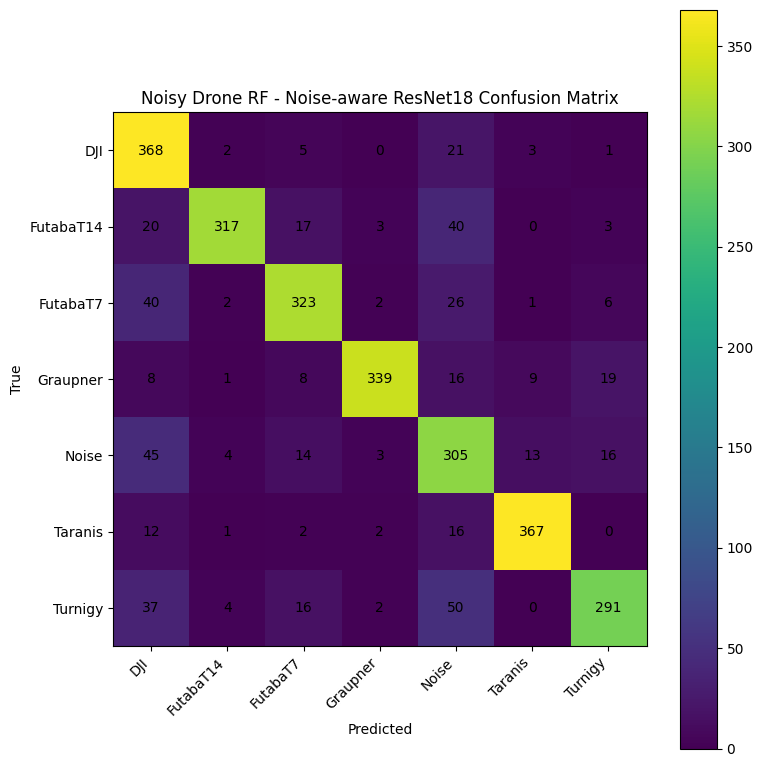

Saved: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced_noise_aware/confusion_matrix_noise_aware.png


,SNR,accuracy
0,-20,0.196262
1,-18,0.351064
2,-16,0.427184
3,-14,0.571429
4,-12,0.656863
5,-10,0.755814
6,-8,0.798077
7,-6,0.901961
8,-4,0.908163
9,-2,0.877049


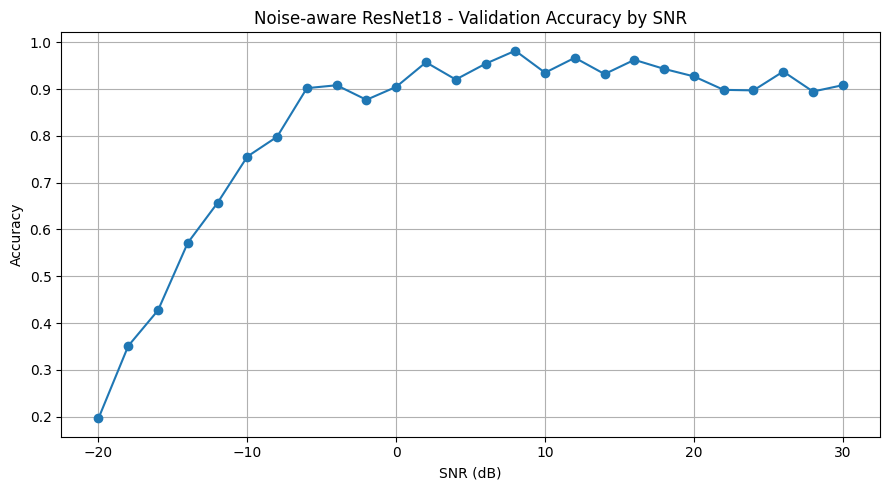

Saved: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced_noise_aware/accuracy_by_snr_noise_aware.png


In [51]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

noise_aware_best_path = os.path.join(SAVE_DIR_NOISE_AWARE, "best_low_snr.pt")
# Alternative:
# noise_aware_best_path = os.path.join(SAVE_DIR_NOISE_AWARE, "best_overall.pt")

noise_aware_eval_model = ResNet18RFSpec(num_classes=len(class_names)).to(device)
noise_aware_eval_model.load_state_dict(torch.load(noise_aware_best_path, map_location=device))
noise_aware_eval_model.eval()

na_preds = []
na_labels = []
na_snrs = []

with torch.no_grad():
    for x, labels, snrs in valid_loader:
        x = x.to(device, non_blocking=True).float()
        labels = labels.to(device, non_blocking=True).long()
        outputs = noise_aware_eval_model(x)
        preds = outputs.argmax(dim=1)

        na_preds.extend(preds.cpu().numpy())
        na_labels.extend(labels.cpu().numpy())
        na_snrs.extend(snrs.cpu().numpy())

print("Loaded:", noise_aware_best_path)
print(classification_report(na_labels, na_preds, target_names=class_names, zero_division=0))

na_results_df = pd.DataFrame({
    "label": np.array(na_labels),
    "pred": np.array(na_preds),
    "snr": np.array(na_snrs),
})
na_results_df["correct"] = na_results_df["label"] == na_results_df["pred"]

overall_acc = na_results_df["correct"].mean()
print(f"Noise-aware overall validation accuracy: {overall_acc:.4f}")

# Overall confusion matrix
cm = confusion_matrix(na_labels, na_preds, labels=list(range(len(class_names))))
plt.figure(figsize=(8, 8))
plt.imshow(cm)
plt.title("Noisy Drone RF - Noise-aware ResNet18 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(np.arange(len(class_names)), class_names)
plt.colorbar()
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, int(cm[i, j]), ha="center", va="center")
plt.tight_layout()
na_cm_path = os.path.join(SAVE_DIR_NOISE_AWARE, "confusion_matrix_noise_aware.png")
plt.savefig(na_cm_path, dpi=200)
plt.show()
print("Saved:", na_cm_path)

# Accuracy by exact SNR
na_snr_acc = na_results_df.groupby("snr")["correct"].mean().reset_index()
na_snr_acc.columns = ["SNR", "accuracy"]
display(na_snr_acc)

plt.figure(figsize=(9, 5))
plt.plot(na_snr_acc["SNR"], na_snr_acc["accuracy"], marker="o")
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy")
plt.title("Noise-aware ResNet18 - Validation Accuracy by SNR")
plt.grid(True)
plt.tight_layout()
na_snr_path = os.path.join(SAVE_DIR_NOISE_AWARE, "accuracy_by_snr_noise_aware.png")
plt.savefig(na_snr_path, dpi=200)
plt.show()
print("Saved:", na_snr_path)


## 21. Compare baseline vs noise-aware by SNR group

This cell compares the old baseline predictions against the new noise-aware predictions.

Expected behavior:

- Low-SNR accuracy should improve.
- Medium/high-SNR accuracy may stay similar or drop slightly.
- If low-SNR improves but high-SNR collapses, reduce the low-SNR weights in Section 18/19.


In [52]:
# Baseline results should exist from the earlier evaluation cell:
# all_labels, all_preds, all_snrs

baseline_results_df = pd.DataFrame({
    "label": np.array(all_labels),
    "pred": np.array(all_preds),
    "snr": np.array(all_snrs),
})
baseline_results_df["correct"] = baseline_results_df["label"] == baseline_results_df["pred"]

snr_groups = {
    "low_snr_-20_to_-10": (-20, -10),
    "medium_snr_-8_to_4": (-8, 4),
    "high_snr_6_to_30": (6, 30),
}

comparison_rows = []
for group_name, (snr_min, snr_max) in snr_groups.items():
    base_subset = baseline_results_df[(baseline_results_df["snr"] >= snr_min) & (baseline_results_df["snr"] <= snr_max)]
    na_subset = na_results_df[(na_results_df["snr"] >= snr_min) & (na_results_df["snr"] <= snr_max)]

    base_acc = base_subset["correct"].mean()
    na_acc = na_subset["correct"].mean()

    comparison_rows.append({
        "snr_group": group_name,
        "snr_min": snr_min,
        "snr_max": snr_max,
        "baseline_samples": len(base_subset),
        "noise_aware_samples": len(na_subset),
        "baseline_acc": base_acc,
        "noise_aware_acc": na_acc,
        "change": na_acc - base_acc,
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

comparison_path = os.path.join(SAVE_DIR_NOISE_AWARE, "baseline_vs_noise_aware_snr_group_comparison.csv")
comparison_df.to_csv(comparison_path, index=False)
print("Saved:", comparison_path)

# Also compare per-class recall by SNR group.
per_class_compare_rows = []
for group_name, (snr_min, snr_max) in snr_groups.items():
    base_subset = baseline_results_df[(baseline_results_df["snr"] >= snr_min) & (baseline_results_df["snr"] <= snr_max)]
    na_subset = na_results_df[(na_results_df["snr"] >= snr_min) & (na_results_df["snr"] <= snr_max)]

    for cls_id, cls_name in enumerate(class_names):
        base_cls = base_subset[base_subset["label"] == cls_id]
        na_cls = na_subset[na_subset["label"] == cls_id]

        base_recall = (base_cls["pred"] == cls_id).mean() if len(base_cls) else np.nan
        na_recall = (na_cls["pred"] == cls_id).mean() if len(na_cls) else np.nan

        per_class_compare_rows.append({
            "snr_group": group_name,
            "class": cls_name,
            "baseline_recall": base_recall,
            "noise_aware_recall": na_recall,
            "change": na_recall - base_recall,
        })

per_class_compare_df = pd.DataFrame(per_class_compare_rows)
display(per_class_compare_df)

per_class_compare_path = os.path.join(SAVE_DIR_NOISE_AWARE, "baseline_vs_noise_aware_per_class_recall.csv")
per_class_compare_df.to_csv(per_class_compare_path, index=False)
print("Saved:", per_class_compare_path)


,snr_group,snr_min,snr_max,baseline_samples,noise_aware_samples,baseline_acc,noise_aware_acc,change
0,low_snr_-20_to_-10,-20,-10,618,618,0.415858,0.488673,0.072816
1,medium_snr_-8_to_4,-8,4,761,761,0.925099,0.896189,-0.028909
2,high_snr_6_to_30,6,30,1421,1421,0.961999,0.933146,-0.028853


Saved: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced_noise_aware/baseline_vs_noise_aware_snr_group_comparison.csv


,snr_group,class,baseline_recall,noise_aware_recall,change
0,low_snr_-20_to_-10,DJI,0.296296,0.629630,0.333333
1,low_snr_-20_to_-10,FutabaT14,0.136364,0.250000,0.113636
2,low_snr_-20_to_-10,FutabaT7,0.238636,0.306818,0.068182
3,low_snr_-20_to_-10,Graupner,0.494253,0.551724,0.057471
4,low_snr_-20_to_-10,Noise,0.919540,0.827586,-0.091954
5,low_snr_-20_to_-10,Taranis,0.534884,0.616279,0.081395
6,low_snr_-20_to_-10,Turnigy,0.306931,0.287129,-0.019802
7,medium_snr_-8_to_4,DJI,0.946429,0.991071,0.044643
8,medium_snr_-8_to_4,FutabaT14,0.937500,0.901786,-0.035714
9,medium_snr_-8_to_4,FutabaT7,0.915094,0.905660,-0.009434


Saved: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced_noise_aware/baseline_vs_noise_aware_per_class_recall.csv


## 22. Noise-aware confusion matrices by SNR group

These matrices should be compared with the baseline SNR-group confusion matrices.

The most important question is whether low-SNR drone/controller samples are still being over-predicted as `Noise`.


Noise-aware low_snr_-20_to_-10: SNR -20 to -10 dB
Samples: 618
Accuracy: 0.4887
              precision    recall  f1-score   support

         DJI       0.34      0.63      0.44        81
   FutabaT14       0.73      0.25      0.37        88
    FutabaT7       0.47      0.31      0.37        88
    Graupner       0.84      0.55      0.67        87
       Noise       0.32      0.83      0.47        87
     Taranis       0.88      0.62      0.73        86
     Turnigy       0.69      0.29      0.41       101

    accuracy                           0.49       618
   macro avg       0.61      0.50      0.49       618
weighted avg       0.62      0.49      0.49       618



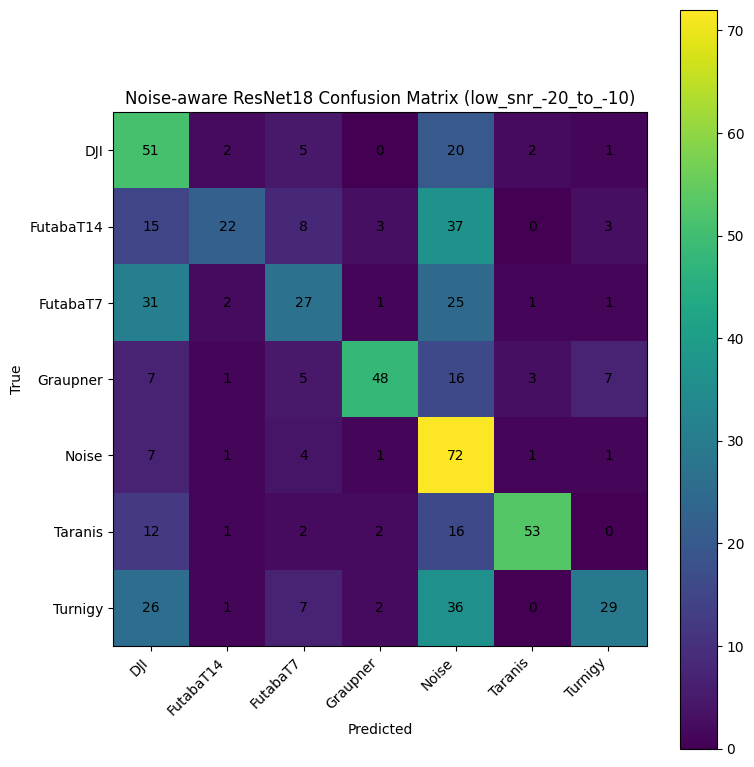

Saved: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced_noise_aware/confusion_matrix_noise_aware_low_snr_-20_to_-10.png
Noise-aware medium_snr_-8_to_4: SNR -8 to 4 dB
Samples: 761
Accuracy: 0.8962
              precision    recall  f1-score   support

         DJI       0.80      0.99      0.88       112
   FutabaT14       0.98      0.90      0.94       112
    FutabaT7       0.85      0.91      0.88       106
    Graupner       0.99      0.94      0.97       119
       Noise       0.84      0.77      0.80       104
     Taranis       0.92      1.00      0.96       111
     Turnigy       0.92      0.73      0.82        97

    accuracy                           0.90       761
   macro avg       0.90      0.89      0.89       761
weighted avg       0.90      0.90      0.90       761



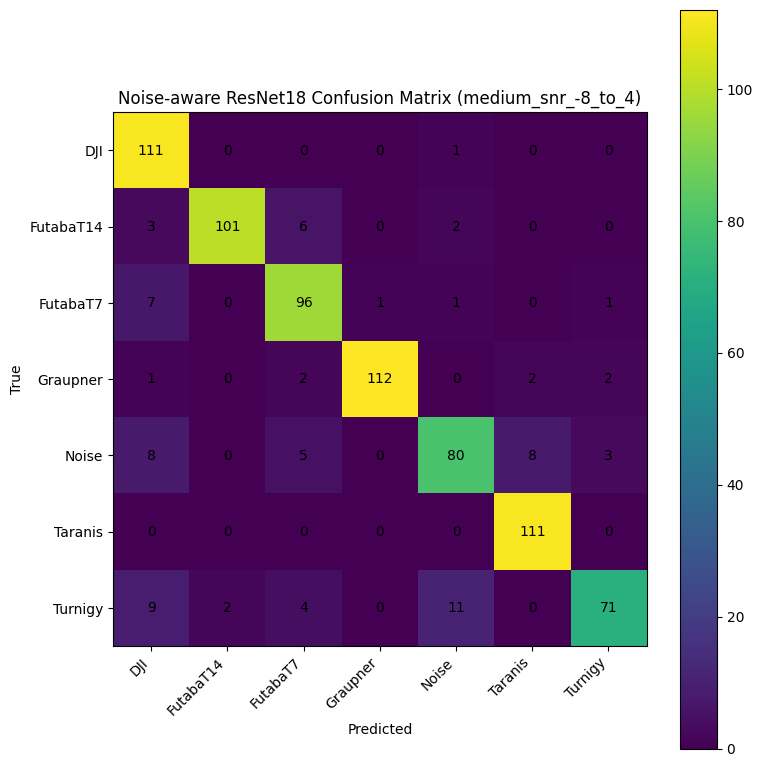

Saved: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced_noise_aware/confusion_matrix_noise_aware_medium_snr_-8_to_4.png
Noise-aware high_snr_6_to_30: SNR 6 to 30 dB
Samples: 1421
Accuracy: 0.9331
              precision    recall  f1-score   support

         DJI       0.85      1.00      0.92       207
   FutabaT14       0.98      0.97      0.97       200
    FutabaT7       0.93      0.97      0.95       206
    Graupner       0.99      0.92      0.95       194
       Noise       0.97      0.73      0.84       209
     Taranis       0.96      1.00      0.98       203
     Turnigy       0.88      0.95      0.91       202

    accuracy                           0.93      1421
   macro avg       0.94      0.93      0.93      1421
weighted avg       0.94      0.93      0.93      1421



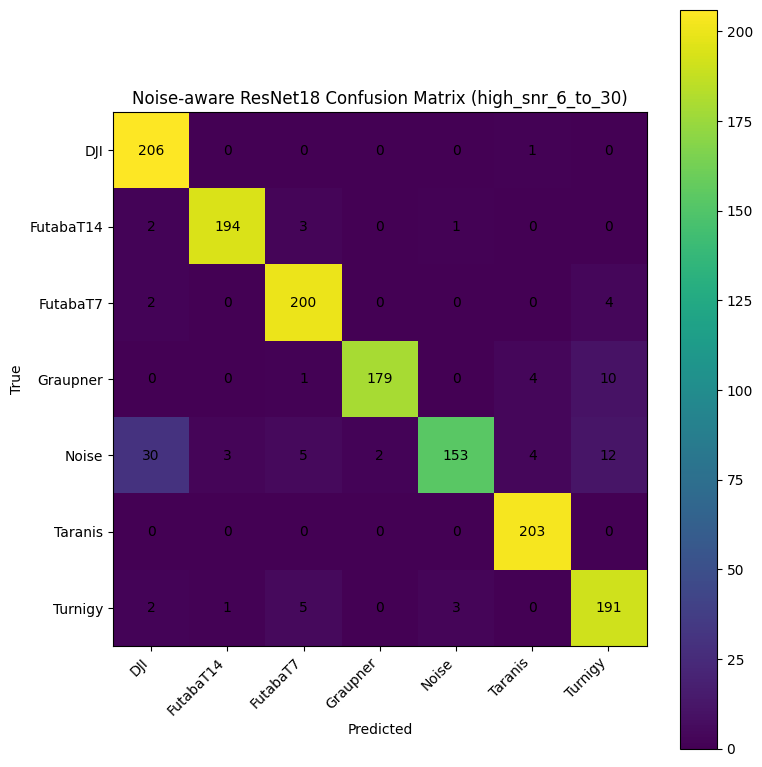

Saved: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced_noise_aware/confusion_matrix_noise_aware_high_snr_6_to_30.png


In [53]:
def plot_cm_from_results(df, title, save_path):
    labels = list(range(len(class_names)))
    cm = confusion_matrix(df["label"], df["pred"], labels=labels)

    plt.figure(figsize=(8, 8))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
    plt.yticks(np.arange(len(class_names)), class_names)
    plt.colorbar()

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            plt.text(j, i, int(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()
    return cm

for group_name, (snr_min, snr_max) in snr_groups.items():
    subset = na_results_df[(na_results_df["snr"] >= snr_min) & (na_results_df["snr"] <= snr_max)].copy()
    acc = subset["correct"].mean()
    print("=" * 80)
    print(f"Noise-aware {group_name}: SNR {snr_min} to {snr_max} dB")
    print(f"Samples: {len(subset)}")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(
        subset["label"], subset["pred"],
        labels=list(range(len(class_names))),
        target_names=class_names,
        zero_division=0,
    ))

    save_path = os.path.join(SAVE_DIR_NOISE_AWARE, f"confusion_matrix_noise_aware_{group_name}.png")
    plot_cm_from_results(
        subset,
        f"Noise-aware ResNet18 Confusion Matrix ({group_name})",
        save_path,
    )
    print("Saved:", save_path)


# Noise-Aware Training Experiment

## Goal

The baseline ResNet18 spectrogram classifier showed strong performance at medium and high SNR, but it struggled in the low-SNR range. The purpose of this experiment was to test whether noise-aware training could improve low-SNR classification performance.

The validation set was divided into three SNR groups:

| SNR Group | Range |
|---|---:|
| Low SNR | -20 to -10 dB |
| Medium SNR | -8 to 4 dB |
| High SNR | 6 to 30 dB |

## Baseline vs Noise-Aware Accuracy

| SNR Group | Baseline Accuracy | Noise-Aware Accuracy | Change |
|---|---:|---:|---:|
| Low SNR (-20 to -10 dB) | 49.68% | 47.41% | -2.27% |
| Medium SNR (-8 to 4 dB) | 91.72% | 87.39% | -4.34% |
| High SNR (6 to 30 dB) | 95.29% | 91.84% | -3.45% |

The noise-aware model did not improve overall performance. Accuracy decreased in all three SNR groups. However, the decrease was smaller than the previous aggressive noise-aware experiment, meaning the milder loss-only approach was less harmful.

## Per-Class Recall Changes

The noise-aware model improved low-SNR recall for some drone/controller classes:

| Class | Baseline Low-SNR Recall | Noise-Aware Low-SNR Recall | Change |
|---|---:|---:|---:|
| DJI | 34.57% | 49.38% | +14.81% |
| FutabaT14 | 22.73% | 28.41% | +5.68% |
| FutabaT7 | 40.91% | 46.59% | +5.68% |
| Taranis | 62.79% | 66.28% | +3.49% |

This shows that the SNR-weighted loss partially helped the model recognize some weak drone/controller signals.

However, the model became worse for other important classes:

| Class | Baseline Low-SNR Recall | Noise-Aware Low-SNR Recall | Change |
|---|---:|---:|---:|
| Noise | 78.16% | 62.07% | -16.09% |
| Turnigy | 47.52% | 28.71% | -18.81% |
| Graupner | 60.92% | 54.02% | -6.90% |

The largest issue is that Noise recall dropped across all SNR groups:

| SNR Group | Baseline Noise Recall | Noise-Aware Noise Recall | Change |
|---|---:|---:|---:|
| Low SNR | 78.16% | 62.07% | -16.09% |
| Medium SNR | 89.42% | 69.23% | -20.19% |
| High SNR | 80.38% | 61.72% | -18.66% |

## Interpretation

The noise-aware loss shifted the model's behavior away from predicting the Noise class. This helped some weak drone/controller signals, especially DJI, FutabaT14, FutabaT7, and Taranis, but it also made the model worse at recognizing true Noise samples.

This creates a trade-off:

- Some low-SNR drone/controller recall improved.
- Noise rejection became significantly worse.
- Overall accuracy decreased in low, medium, and high SNR ranges.

Because the dataset includes Noise as one of the target classes, reducing Noise recall is a serious problem. A useful model should not only detect weak drone/controller signals, but also correctly reject background noise.

## Conclusion

The baseline ResNet18 remains the better model overall. The noise-aware loss-only experiment did not improve the full 7-class classification task. It slightly improved recall for some low-SNR drone classes, but this came at the cost of much worse Noise classification and lower total accuracy.

This result suggests that simple SNR-weighted loss is not enough for this dataset. The model may need a method that improves robustness without changing the class decision boundary too strongly.